In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import itertools as it
import scipy.stats.qmc as ssq
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from skopt import BayesSearchCV
from skopt.space.space import Real, Integer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

np.set_printoptions(threshold=100_000)
X = pd.read_csv(r"C:\Users\dwigh\OneDrive\Desktop\Emissions Uncertainty on Antarctic Instability\ensemble_output\results\default\parameters.csv")

Y = pd.read_csv(r"C:\Users\dwigh\OneDrive\Desktop\Emissions Uncertainty on Antarctic Instability\ensemble_output\results\default\gmslr.csv")
Y = Y.sum(axis=1).rename('output')
obj = X.join(Y, how='left')
obj.sort_values(by='t_peak',ascending=True, inplace=True)


In [2]:
# obj.t_peak = pd.to_datetime(obj.t_peak, format='%Y')
obj.set_index('t_peak',drop=False, inplace=True)
obj

,gamma_g,t_peak,gamma_d,sd_temp,sd_ocean_heat,sd_glaciers,sd_greenland,sd_antarctic,sd_gmsl,rho_temperature,...,antarctic_kappa,antarctic_flow0,antarctic_runoff_height0,antarctic_c,antarctic_bed_height0,antarctic_slope,antarctic_lambda,antarctic_temp_threshold,lw_random_sample,output
t_peak,,,,,,,,,,,,,,,,,,,,,
2030.0,0.005979,2030.0,0.091974,0.074738,2.503238,0.000198,0.000232,0.000383,0.000405,0.467965,...,0.072566,1.072699,1240.514180,79.039386,762.770179,0.000707,0.008297,-15.740854,0.000261,194.280258
2030.0,0.009668,2030.0,0.081546,0.081082,1.851315,0.000132,0.000251,0.000502,0.001941,0.369884,...,0.076086,1.323465,1014.354512,126.821100,807.992695,0.000624,0.013372,-15.546083,0.000092,156.887510
2030.0,0.002629,2030.0,0.149528,0.082100,1.756363,0.000159,0.000247,0.000475,0.002613,0.506711,...,0.059001,1.328616,1737.814817,119.263273,809.343880,0.000708,0.006230,-15.540414,0.000242,164.789451
2030.0,0.003917,2030.0,0.081056,0.087278,2.841193,0.000082,0.000239,0.000466,0.001685,0.355840,...,0.054435,0.993865,1136.483270,140.548806,816.925800,0.000684,0.006855,-15.453124,0.000164,176.265314
2030.0,0.008057,2030.0,0.112075,0.077741,1.353660,0.000495,0.000276,0.000340,0.001981,0.538458,...,0.055346,1.470483,991.781103,97.797643,807.736344,0.000556,0.010325,-14.959565,0.000641,221.801617
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2167.0,0.013229,2167.0,0.093814,0.080127,1.034033,0.000253,0.000202,0.000538,0.000763,0.518355,...,0.069314,1.460019,1379.251183,117.385686,797.296496,0.000668,0.011739,-16.190533,0.000739,1414.150176
2169.0,0.003130,2169.0,0.022636,0.079961,2.088501,0.000069,0.000217,0.000380,0.001736,0.665597,...,0.065737,1.516385,1673.690577,136.186139,787.740252,0.000562,0.012827,-16.224729,0.000183,955.432608
2171.0,0.004158,2171.0,0.120120,0.078078,0.375789,0.000049,0.000264,0.000451,0.002437,0.763427,...,0.080312,0.812621,1340.939748,76.307069,798.575153,0.000548,0.009879,-15.795974,0.000354,1010.240136


In [ ]:
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')
obj.output.plot(figsize=(15,5),color=color_pal[0], kind='kde')
plt.show()

In [ ]:
def add_lags(data: pd.DataFrame):
    new_data = data.copy()
    index = pd.to_datetime(new_data.t_peak, format='%Y')
    target_map = new_data['output'].to_dict()
    lag1 =  (index - pd.Timedelta('365 days')).dt.year
    lag2 = (index - pd.Timedelta('730 days')).dt.year
    lag3 = (index - pd.Timedelta('1095 days')).dt.year
    lag4 = (index - pd.Timedelta('1460 days')).dt.year
    new_data['lag1'] = lag1.map(target_map)
    new_data['lag2'] = lag2.map(target_map)
    new_data['lag3'] = lag3.map(target_map)
    new_data['lag4'] = lag4.map(target_map)
    return new_data

In [46]:
new_obj = add_lags(obj)
new_obj

,gamma_g,t_peak,gamma_d,sd_temp,sd_ocean_heat,sd_glaciers,sd_greenland,sd_antarctic,sd_gmsl,rho_temperature,...,antarctic_bed_height0,antarctic_slope,antarctic_lambda,antarctic_temp_threshold,lw_random_sample,output,lag1,lag2,lag3,lag4
t_peak,,,,,,,,,,,,,,,,,,,,,
2030.0,0.005979,2030.0,0.091974,0.074738,2.503238,0.000198,0.000232,0.000383,0.000405,0.467965,...,762.770179,0.000707,0.008297,-15.740854,0.000261,194.280258,193.985971,213.333758,213.333758,207.291920
2030.0,0.009668,2030.0,0.081546,0.081082,1.851315,0.000132,0.000251,0.000502,0.001941,0.369884,...,807.992695,0.000624,0.013372,-15.546083,0.000092,156.887510,193.985971,213.333758,213.333758,207.291920
2030.0,0.002629,2030.0,0.149528,0.082100,1.756363,0.000159,0.000247,0.000475,0.002613,0.506711,...,809.343880,0.000708,0.006230,-15.540414,0.000242,164.789451,193.985971,213.333758,213.333758,207.291920
2030.0,0.003917,2030.0,0.081056,0.087278,2.841193,0.000082,0.000239,0.000466,0.001685,0.355840,...,816.925800,0.000684,0.006855,-15.453124,0.000164,176.265314,193.985971,213.333758,213.333758,207.291920
2030.0,0.008057,2030.0,0.112075,0.077741,1.353660,0.000495,0.000276,0.000340,0.001981,0.538458,...,807.736344,0.000556,0.010325,-14.959565,0.000641,221.801617,193.985971,213.333758,213.333758,207.291920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2167.0,0.013229,2167.0,0.093814,0.080127,1.034033,0.000253,0.000202,0.000538,0.000763,0.518355,...,797.296496,0.000668,0.011739,-16.190533,0.000739,1414.150176,NaN,NaN,955.432608,NaN
2169.0,0.003130,2169.0,0.022636,0.079961,2.088501,0.000069,0.000217,0.000380,0.001736,0.665597,...,787.740252,0.000562,0.012827,-16.224729,0.000183,955.432608,NaN,1010.240136,932.069957,932.069957
2171.0,0.004158,2171.0,0.120120,0.078078,0.375789,0.000049,0.000264,0.000451,0.002437,0.763427,...,798.575153,0.000548,0.009879,-15.795974,0.000354,1010.240136,932.069957,932.069957,NaN,NaN


In [47]:
new_obj1 = new_obj.copy()
output = new_obj1.pop('output')
new_obj1.insert(57, 'output', output)

In [49]:
val = TimeSeriesSplit(n_splits=4, max_train_size=60_000)
features = new_obj1.iloc[:,:-1].columns
target = new_obj1.iloc[:,-1].name
scores = {'Train Error':list(), 'Test Error': list()}
folds = 0
for train_indx, val_indx in val.split(new_obj1):
    train = new_obj1.iloc[train_indx]
    test = new_obj1.iloc[val_indx]

    X_train = train[features]
    Y_train = train[target]
    X_test = test[features]
    Y_test = test[target]
    RF = RandomForestRegressor(n_estimators=300,max_depth=30, n_jobs=20, random_state=0)
    RF.fit(X_train, Y_train)
    y_pred = RF.predict(X_train)
    y_tpred = RF.predict(X_test)
    val_error = np.square(Y_test - y_tpred).mean()
    train_error = np.square(Y_train - y_pred).mean()
    print(f'[{folds}]Training MSE:\t{train_error}\t Validation MSE:\t{val_error}')
    scores['Train Error'].append(train_error)
    scores['Test Error'].append(val_error)
    folds+=1
print(f'Mean Training MSE\t{sum(scores['Train Error'])/len(scores['Train Error'])}')
print(f'Mean Testing MSE:\t{sum(scores['Test Error'])/len(scores['Test Error'])}')

[0]Training MSE:	338.3299362492211	 Validation MSE:	13500.753445544582
[1]Training MSE:	393.8334566767536	 Validation MSE:	13580.243212054267
[2]Training MSE:	432.0143775607556	 Validation MSE:	13627.616767609945
[3]Training MSE:	498.41129004274313	 Validation MSE:	22468.674807879335
Mean Training MSE	415.6472651323683
Mean Testing MSE:	15794.322058272031


In [50]:
val1 = train_test_split(new_obj1.iloc[:,:-1], new_obj1.iloc[:,-1],shuffle=False, train_size=0.8, random_state=0)
RF = RandomForestRegressor(n_estimators=300, n_jobs=20, random_state=0)
RF.fit(val1[0],val1[2])

RandomForestRegressor(n_estimators=300, n_jobs=20, random_state=0)

In [51]:
RF.feature_importances_

array([0.04106161, 0.29663812, 0.1583766 , 0.00161626, 0.00157607,
       0.00165781, 0.00173705, 0.00197579, 0.00174735, 0.0016694 ,
       0.00157273, 0.00157713, 0.00224959, 0.00162296, 0.00226394,
       0.00164785, 0.00160471, 0.0022079 , 0.00208593, 0.00157808,
       0.00168454, 0.00167415, 0.001595  , 0.00156853, 0.00543303,
       0.00172004, 0.00213497, 0.00180028, 0.00822693, 0.18393769,
       0.00216268, 0.00313723, 0.00408822, 0.00216003, 0.00465906,
       0.00149971, 0.00159425, 0.00192668, 0.00155542, 0.00155375,
       0.00164364, 0.00603349, 0.00167953, 0.00243833, 0.0017216 ,
       0.00187401, 0.00199992, 0.00168528, 0.00155221, 0.00153291,
       0.08734611, 0.12102844, 0.00288253, 0.00138155, 0.00136563,
       0.00145369, 0.00180207])

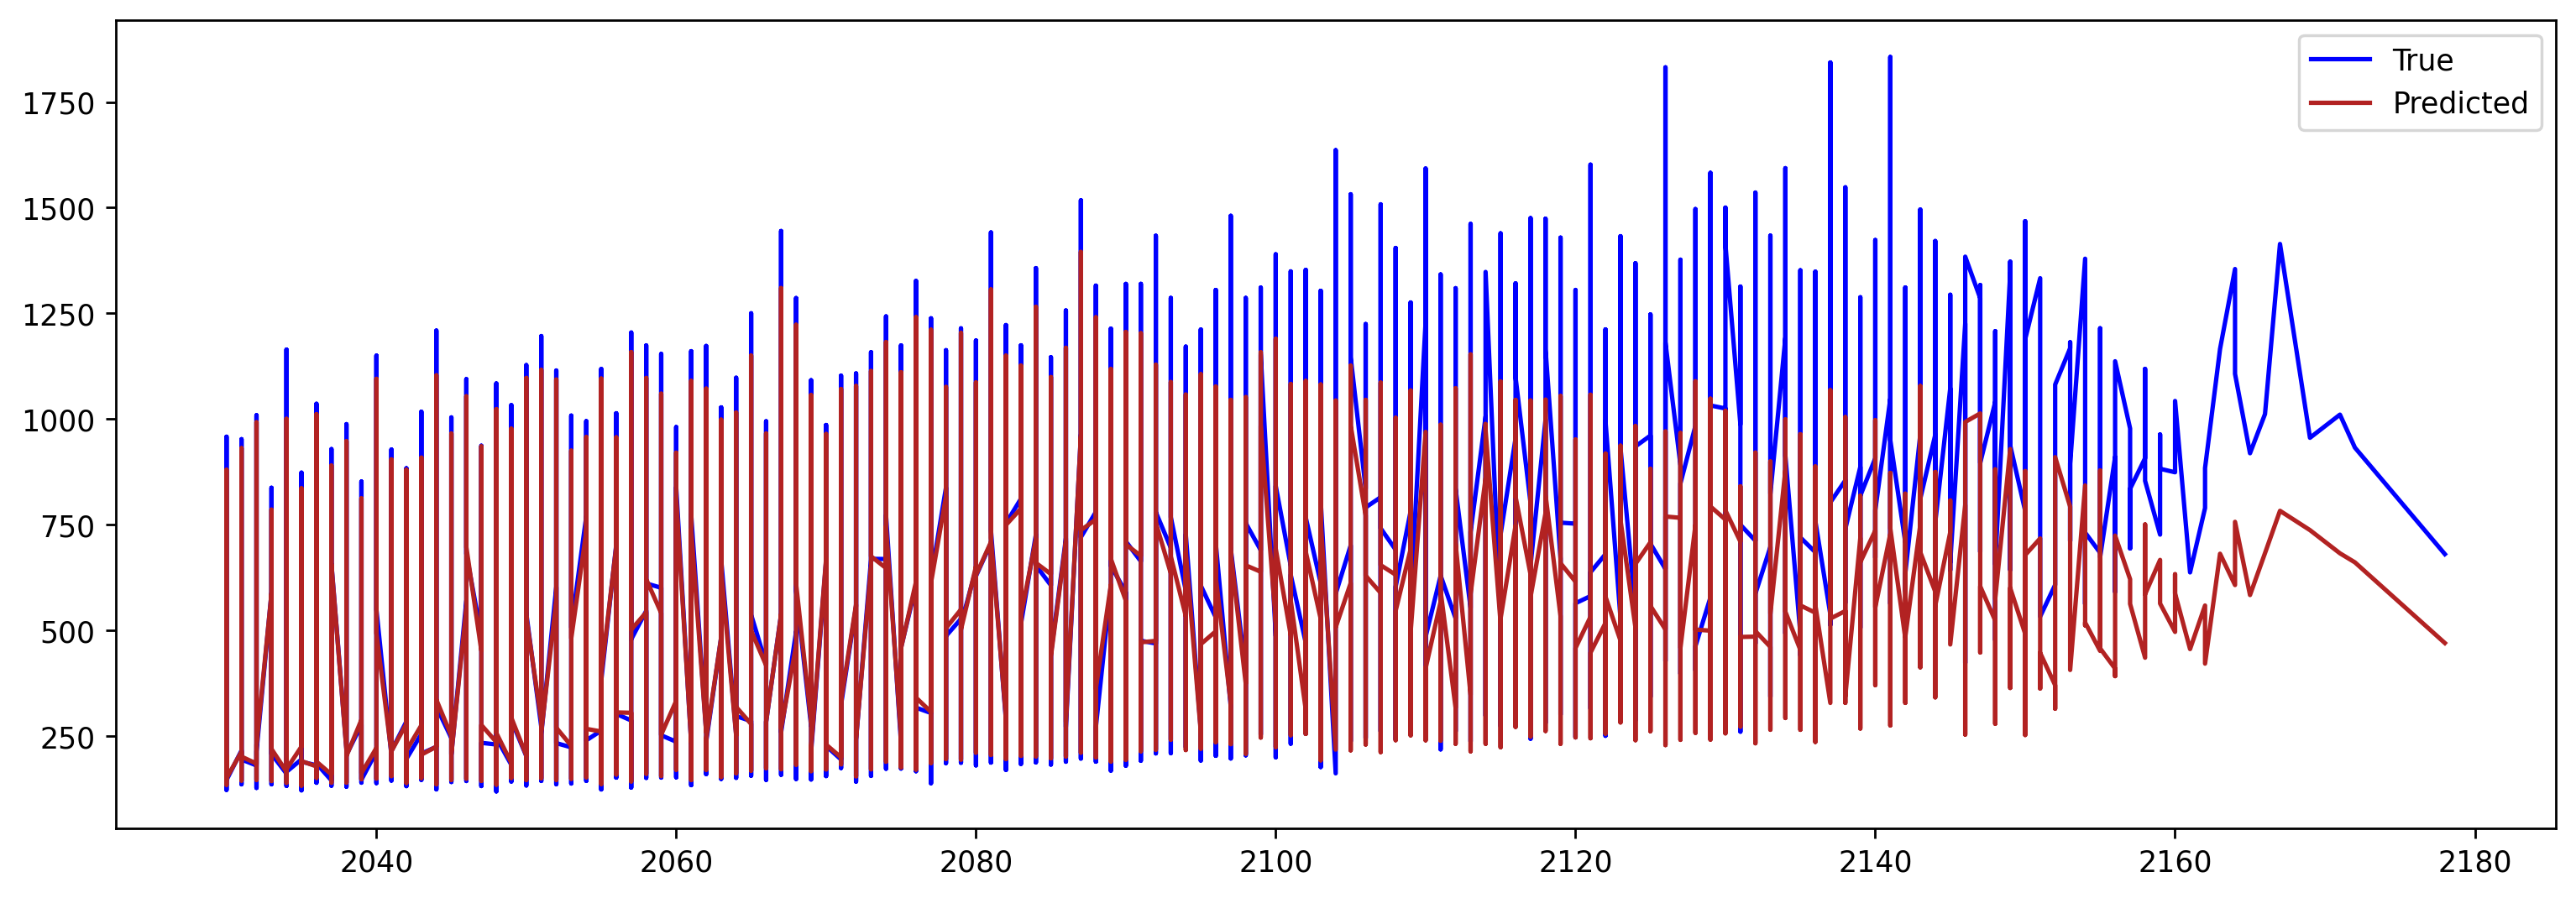

In [52]:
fig, ax = plt.subplots(1,1, figsize=(15,5), dpi=250)
ax.plot(new_obj1.t_peak, new_obj1.output, color='blue', label='True')
ax.plot(new_obj1.t_peak, RF.predict(new_obj1.iloc[:,:-1]), color='firebrick', label='Predicted')
ax.legend()
plt.show()

In [ ]:
rng = np.random.default_rng(seed=0)
def bootstrapp(y_true,y_pred,n_boots):
    rows = len(y_true)
    error = (y_true - y_pred).to_numpy()
    S_CI = np.zeros((n_boots,))
    for i in range(n_boots):
        indx = rng.choice(rows, size=rows, replace=True)
        S_CI[i] = np.mean(np.square(error[indx]))
    return S_CI

In [ ]:
def mod_pvi1(data: pd.DataFrame, y_true: np.ndarray[float], f: callable,*, n_boots: int, alpha: float, column_set: dict) -> tuple[pd.DataFrame]:
    rows, columns = data.shape
    npv_columns = column_set
    V_y = np.var(y_true, ddof=1)
    u = dict()
    CI = dict()
    rolled_data = pd.DataFrame(np.roll(data.copy(),rows//2, axis=0), columns=data.columns)
    # rolled_data = np.roll(data.copy(), rows//2, axis=0)
    for col in npv_columns:
        d = rolled_data.copy()
        d[col] = data[col].to_numpy()
        y_pred = f(d)
        u[col] = 1-np.mean(np.square(y_true - y_pred))/(2*V_y)
        S_CI = 1 - bootstrapp(y_true,y_pred, n_boots)/(2*V_y)
        p0,p1 = np.quantile(S_CI, [alpha,1-alpha])
        CI[col] = [p0,p1,p1-p0]
    CI = pd.DataFrame(CI.values(), index = CI.keys(), columns=['5th','95th','Quantile Difference'])
    CI.index.name = 'Interactions'
    CI.columns.name = 'Confidence Interval Difference'
    SI = pd.DataFrame(u.values(), index=u.keys(), columns=['$P_{i}$'])
    return u,CI

In [ ]:
def mod_pvi_t(data: np.ndarray[float], y_true: np.ndarray[float], f: callable,*,n_boots: int, alpha: float, column_set: list[str]) -> np.ndarray[float]:
    '''
    ===Total-Order Permutation Variable Importances===

        data: your training dataset
        y_pred: your model output (specifically the prediction of your 'data' arg)
        f: in this case, simply RF.predict
    '''
    rows, columns = data.shape
    npv_columns = column_set
    u = dict()
    V_y = np.var(y_true,ddof=1 )
    CI = dict()
    for col in npv_columns:
        d = data.copy()
        d[col] = np.roll(data[col],rows//2, axis=0)
        y_pred = f(d)
        u[col] = np.mean(np.square(y_true - y_pred))/(2*V_y)
        S_CI = bootstrapp(y_true,y_pred, n_boots)/(2*V_y)
        p0,p1 = np.quantile(S_CI, [alpha,1-alpha])
        CI[col] = [p0,p1,p1-p0]
    CI = pd.DataFrame(CI.values(), index = CI.keys(), columns=['5th','95th','Quantile Difference'])
    CI.index.name = 'Interactions'
    CI.columns.name = 'Confidence Interval Difference'
    S_t = pd.DataFrame(u.values(), index=u.keys(), columns=[r'$P_{\tau}$'])
    return u, CI

In [ ]:
def mod_pvi2(data: pd.DataFrame, y_true: np.ndarray[float], f: callable,*,PI:dict, n_boots: int, alpha: float, column_set: dict) -> tuple[pd.DataFrame]:
    rows, columns = data.shape
    npv_columns = column_set
    V_y = np.var(y_true, ddof=1)
    u = dict()
    CI = dict()
    rolled_data = pd.DataFrame(np.roll(data.copy(),rows//2, axis=0), columns=data.columns)
    # rolled_data = np.roll(data.copy(), rows//2, axis=0)
    for col1, col2 in it.combinations(npv_columns,r=2):
        col = col1+','+col2
        d = rolled_data.copy()
        d[[col1,col2]] = data[[col1,col2]].to_numpy()
        y_pred = f(d)
        u[col] = 1-np.mean(np.square(y_true - y_pred))/(2*V_y) - PI[col1] - PI[col2]
        print(f'Columns:{col}\t{u[col]}')
        S_CI = 1 - bootstrapp(y_true,y_pred, n_boots)/(2*V_y) - PI[col1] - PI[col2]
        p0,p1 = np.quantile(S_CI, [alpha,1-alpha])
        CI[(col1, col2)] = [p0,p1,p1-p0]
    CI = pd.DataFrame(CI.values(), index = CI.keys(), columns=['5th','95th','Quantile Difference'])
    CI.index.name = 'Interactions'
    CI.columns.name = 'Confidence Interval Difference'
    SI = pd.DataFrame(u.values(), index=u.keys(), columns=['$P_{i}$'])
    return u,CI

In [ ]:
PI, CI = mod_pvi1(val1[0], val1[2], RF.predict, n_boots=1000, alpha=0.05, column_set=val1[0].columns)

In [ ]:
PI

In [ ]:
PT, CT = mod_pvi_t(val1[0], val1[2], RF.predict, n_boots=1000, alpha=0.05, column_set=val1[0].columns)

In [ ]:
PT

In [ ]:
PIK, CIK = mod_pvi2(val1[0], val1[2], RF.predict,PI=PI, n_boots=1000, alpha=0.05, column_set=val1[0].columns)